In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [9]:
df = pd.read_csv("Customer Churn new.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,EstimatedSalary,Exited
0,747,15787619,Hsieh,844,France,Male,18,2,160980.03,145936.28,0
1,1620,15770309,McDonald,656,France,Male,18,10,151762.74,127014.32,0
2,1679,15569178,Kharlamov,570,France,Female,18,4,82767.42,71811.90,0
3,2022,15795519,Vasiliev,716,Germany,Female,18,3,128743.80,197322.13,0
4,2137,15621893,Bellucci,727,France,Male,18,4,133550.67,46941.41,0


In [10]:
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

In [11]:
df = df.dropna()

In [12]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [15]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [16]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [17]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.6, random_state=42
)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
y_val_pred = rf_model.predict(X_val)

print("Validation Results:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1 Score:", f1_score(y_val, y_val_pred))

Validation Results:
Accuracy: 0.806
Precision: 0.550561797752809
Recall: 0.2413793103448276
F1 Score: 0.3356164383561644


In [21]:
y_test_pred = rf_model.predict(X_test)

print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))


Test Results:
Accuracy: 0.8093333333333333
Precision: 0.6106870229007634
Recall: 0.25396825396825395
F1 Score: 0.35874439461883406


In [22]:
cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[1134   51]
 [ 235   80]]


In [23]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1185
           1       0.61      0.25      0.36       315

    accuracy                           0.81      1500
   macro avg       0.72      0.61      0.62      1500
weighted avg       0.78      0.81      0.78      1500



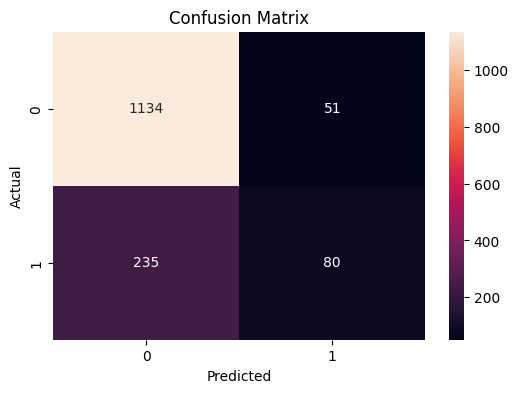

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()